In [2]:
import cv2
import os
import random
import numpy as np

In [6]:
mydir = r'C:\Users\anjal\Deep_learning\CNN\catvsdog\data\train_new'

In [7]:
categories = ['cats','dogs']

In [8]:
data = []

for i in categories:
    folder_path = os.path.join(mydir,i)
    if i == 'cats':
        label = 0
    else:
        label = 1
    for j in os.listdir(folder_path):
        img_path = os.path.join(folder_path,j)
        img = cv2.imread(img_path)
        img = cv2.resize(img,(150,150))
        data.append([img,label])

In [9]:
random.shuffle(data)

In [10]:
X =[]
y =[]
for i in data:
    X.append(i[0])
    y.append(i[1])

In [11]:
y = np.array(y)

In [12]:
X = np.array(X)

In [13]:
X.shape


(2000, 150, 150, 3)

In [14]:
X = X/255

In [15]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Activation,Dropout,Dense

In [16]:
model = Sequential()
model.add(Conv2D(32,(3,3),input_shape = (150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))



c:\Users\anjal\.conda\envs\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='rmsprop',metrics=['accuracy'])

In [18]:
model.fit(X,y,epochs=5,validation_split=0.1)

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.5122 - loss: 0.7064 - val_accuracy: 0.5400 - val_loss: 0.6873
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.5217 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6767
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6017 - loss: 0.6713 - val_accuracy: 0.5750 - val_loss: 0.6356
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6467 - loss: 0.6367 - val_accuracy: 0.6850 - val_loss: 0.5987
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.6856 - loss: 0.6021 - val_accuracy: 0.7050 - val_loss: 0.5813


In [19]:
import matplotlib.pyplot as plt

In [20]:
import cv2

In [21]:
test_img = cv2.imread(r'C:\Users\anjal\Deep_learning\CNN\cat.jpg')

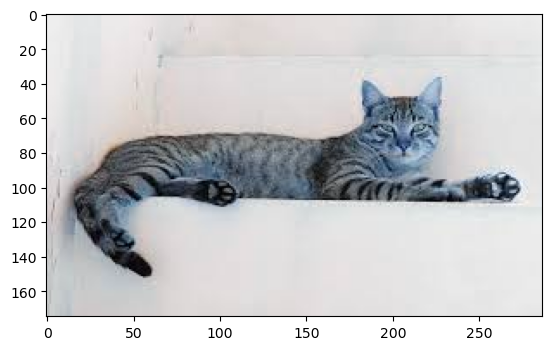

In [22]:
plt.imshow(test_img)

In [23]:
test_img = cv2.resize(test_img,(150,150))

In [24]:
test_input = test_img.reshape((1,150,150,3))

In [25]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


array([[0.]], dtype=float32)